# 1.Problem Definition
Predict `salary_in_usd` for data-science roles using job and company attributes.

Workflow: Problem -> Data -> Clean -> Explore -> Features -> Model -> Evaluate -> Deploy

# 2. Data collection
Loading the data.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import joblib

DF = pd.read_csv('ds_salaries.csv')
TARGET = 'salary_in_usd'
DF.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,269355,USD,269355,ES,100,ES,L
1,2023,MI,CT,ML Engineer,179942,USD,179942,US,100,US,S
2,2023,MI,CT,ML Engineer,189365,USD,189365,US,100,US,S
3,2023,SE,FT,Data Scientist,257959,USD,257959,CA,100,CA,M
4,2023,SE,FT,Data Scientist,236892,USD,236892,CA,100,CA,M


# 3.Clean
Handle missing values and preprocess features for modeling.

In [23]:
DF = DF.dropna(subset=[TARGET]).drop_duplicates().reset_index(drop=True)

X_raw = DF.drop(columns=[TARGET, 'salary', 'salary_currency'], errors='ignore')
y = DF[TARGET]

categorical_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_raw.select_dtypes(exclude=['object']).columns.tolist()

X_clean = X_raw.copy()
X_clean[numeric_cols] = X_clean[numeric_cols].fillna(X_clean[numeric_cols].median())
X_clean[categorical_cols] = X_clean[categorical_cols].fillna('missing')

X = pd.get_dummies(X_clean, columns=categorical_cols, drop_first=False)

print(f'Rows after cleaning: {len(DF):,}')
print(f'Raw feature columns: {X_raw.shape[1]}')
print(f'Model-ready feature columns: {X.shape[1]}')
X_raw.shape

Rows after cleaning: 3,852
Raw feature columns: 8
Model-ready feature columns: 256


(3852, 8)

# 4.Explore
Quick checks to understand data shape, nulls, and salary distribution.

In [24]:
display(DF.info())
display(DF.describe(include='all').T.head(10))

missing = DF.isna().sum().sort_values(ascending=False)
print('Top missing columns:')
print(missing.head(10))

print('\nTarget summary:')
print(y.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3852 entries, 0 to 3851
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3852 non-null   int64 
 1   experience_level    3852 non-null   object
 2   employment_type     3852 non-null   object
 3   job_title           3852 non-null   object
 4   salary              3852 non-null   int64 
 5   salary_currency     3852 non-null   object
 6   salary_in_usd       3852 non-null   int64 
 7   employee_residence  3852 non-null   object
 8   remote_ratio        3852 non-null   int64 
 9   company_location    3852 non-null   object
 10  company_size        3852 non-null   object
dtypes: int64(4), object(7)
memory usage: 331.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3852.0,NaN,NaN,NaN,2022.388889,0.68962,2020.0,2022.0,2022.0,2023.0,2023.0
experience_level,3852,4,SE,2590,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3852,4,FT,3813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3852,93,Data Engineer,1063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3852.0,NaN,NaN,NaN,218306.467809,30965.675797,94762.0,202356.75,225002.0,238420.75,318354.0
salary_currency,3852,1,USD,3852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3852.0,NaN,NaN,NaN,218306.467809,30965.675797,94762.0,202356.75,225002.0,238420.75,318354.0
employee_residence,3852,78,US,3080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,3852.0,NaN,NaN,NaN,46.222741,48.604362,0.0,0.0,0.0,100.0,100.0
company_location,3852,72,US,3117,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Top missing columns:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
dtype: int64

Target summary:
count      3852.000000
mean     218306.467809
std       30965.675797
min       94762.000000
25%      202356.750000
50%      225002.000000
75%      238420.750000
max      318354.000000
Name: salary_in_usd, dtype: float64


# 4.1 Visualize
Create quick visuals to understand salary patterns before modeling.

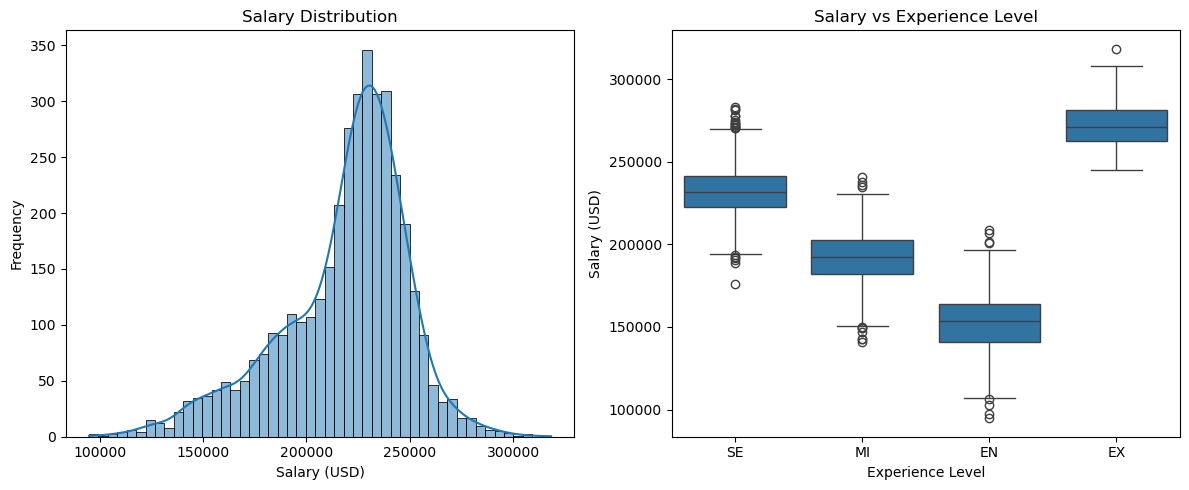

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(DF[TARGET], kde=True, ax=axes[0])
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary (USD)")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=DF['experience_level'], y=DF[TARGET], ax=axes[1])
axes[1].set_title("Salary vs Experience Level")
axes[1].set_xlabel("Experience Level")
axes[1].set_ylabel("Salary (USD)")

plt.tight_layout()
plt.show()

### Outlier Scatterplot
Highlight salary outliers using the IQR rule.

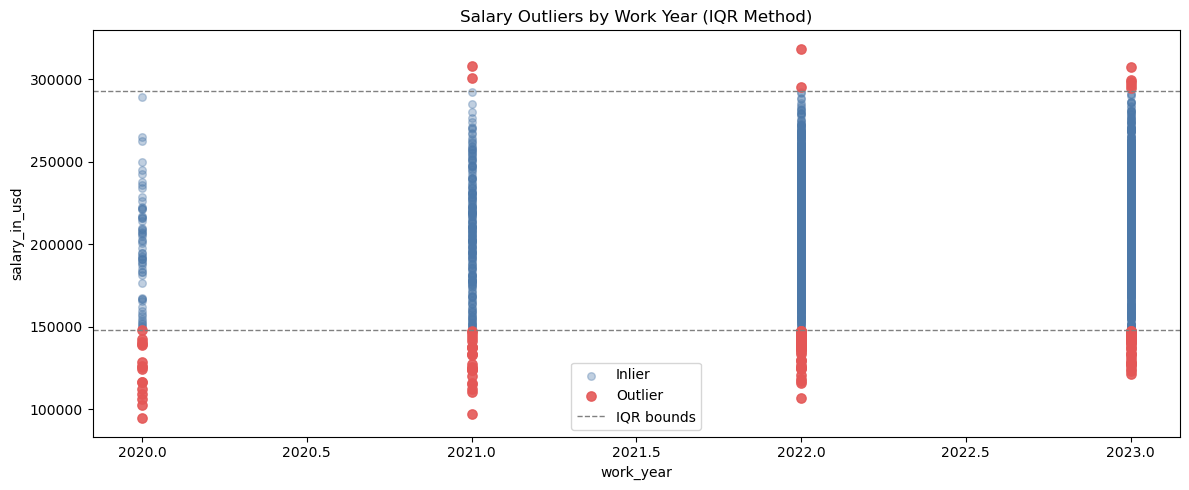

Outliers detected: 148 out of 3852 rows


In [26]:
q1 = DF[TARGET].quantile(0.25)
q3 = DF[TARGET].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

is_outlier = (DF[TARGET] < lower_bound) | (DF[TARGET] > upper_bound)

plt.figure(figsize=(12, 5))
plt.scatter(
    DF.loc[~is_outlier, 'work_year'],
    DF.loc[~is_outlier, TARGET],
    alpha=0.35,
    s=30,
    color='#4C78A8',
    label='Inlier'
  )
plt.scatter(
    DF.loc[is_outlier, 'work_year'],
    DF.loc[is_outlier, TARGET],
    alpha=0.9,
    s=45,
    color='#E45756',
    label='Outlier'
  )
plt.axhline(lower_bound, color='gray', linestyle='--', linewidth=1, label='IQR bounds')
plt.axhline(upper_bound, color='gray', linestyle='--', linewidth=1)
plt.title('Salary Outliers by Work Year (IQR Method)')
plt.xlabel('work_year')
plt.ylabel('salary_in_usd')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Outliers detected: {is_outlier.sum()} out of {len(DF)} rows')

# 5.Features
Inspect raw and model-ready feature groups.

In [27]:
print(f'Numeric raw features: {len(numeric_cols)}')
print(f'Categorical raw features: {len(categorical_cols)}')

Numeric raw features: 2
Categorical raw features: 6


# 6.Model
Train two models `RandomForestRegressor` and `LinearRegression`


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

trained_models = {
    'Random Forest': rf_model,
    'Linear Regression': lr_model
}

predictions = {
    'Random Forest': rf_preds,
    'Linear Regression': lr_preds
}

model = trained_models['Random Forest']

# 7.Evaluate
Report regression metrics on the holdout test set.

In [29]:
results = []

for model_name, preds in predictions.items():
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    results.append({
        'Model': model_name,
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
display(results_df.style.format({'R2 Score': '{:.4f}', 'MAE': '{:,.2f}', 'RMSE': '{:,.2f}'}))

,Model,R2 Score,MAE,RMSE
1,Linear Regression,0.8358,"9,908.93","12,639.11"
0,Random Forest,0.8327,"10,127.05","12,758.30"


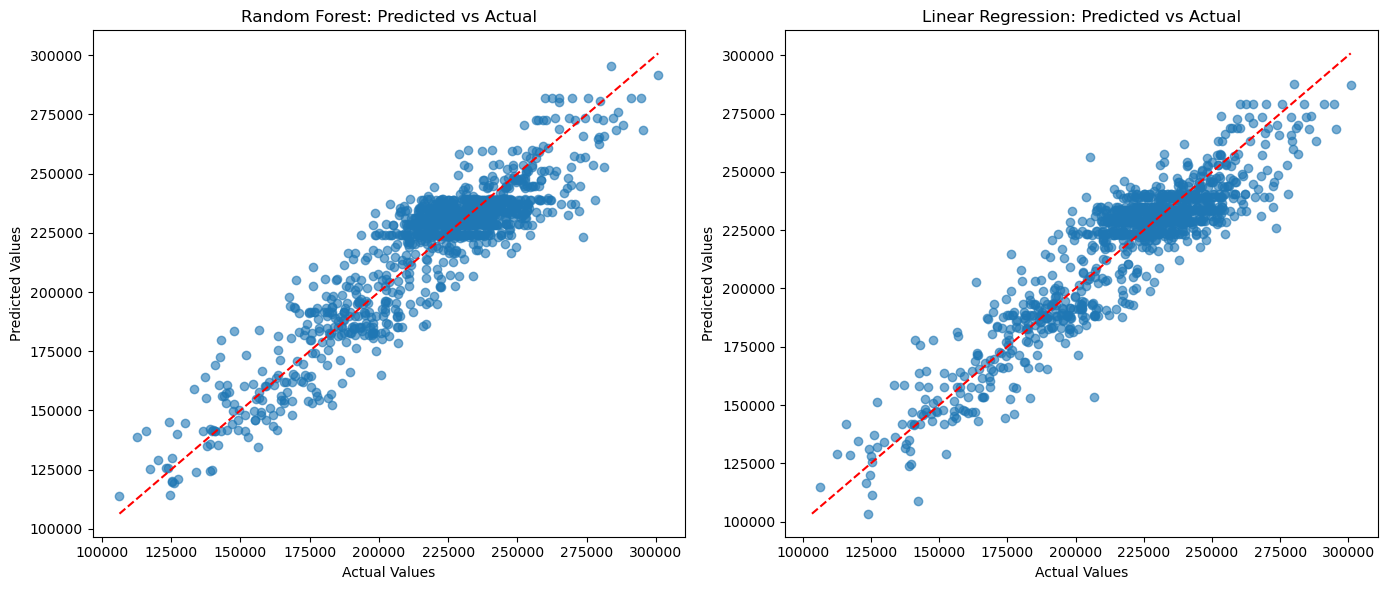

In [30]:
def plot_pred_vs_actual(y_true, y_pred, model_name, ax):
    ax.scatter(y_true, y_pred, alpha=0.6)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red')
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(f"{model_name}: Predicted vs Actual")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_pred_vs_actual(y_test, rf_preds, "Random Forest", axes[0])

plot_pred_vs_actual(y_test, lr_preds, "Linear Regression", axes[1])

plt.tight_layout()
plt.show()

We selected linear regression as our model because the dataset exhibits a predominantly linear relationship between the input features and the target variable. This makes linear regression a suitable and interpretable choice for capturing the underlying pattern in the data.

Although both models produced comparable performance, with ( R^2 ) scores of approximately 0.83, linear regression demonstrated a slight edge in terms of accuracy. In addition to this marginal improvement, linear regression offers advantages such as simplicity, ease of implementation, and clear interpretability of results, which are important for understanding the influence of individual features.

Considering both the nature of the data and the performance metrics, linear regression was chosen as the final model, as it provides a good balance between predictive accuracy and model transparency.

# 8.Deploy
Save artifacts and create a sample prediction payload for deployment integration.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

model = lr_model

In [32]:
joblib.dump(model, 'salary_model.joblib')
sample_payload = X_test.head(1).to_dict(orient='records')[0]
print('Model saved to salary_model.joblib')

Model saved to salary_model.joblib


# Testing for overfitting and underfitting
By comparing train and test performance

In [33]:
# --- RANDOM FOREST ---
rf_train_preds = rf_model.predict(X_train)
rf_test_preds = rf_model.predict(X_test)

rf_train_r2 = r2_score(y_train, rf_train_preds)
rf_test_r2 = r2_score(y_test, rf_test_preds)

# --- LINEAR REGRESSION ---
lr_train_preds = lr_model.predict(X_train)
lr_test_preds = lr_model.predict(X_test)

lr_train_r2 = r2_score(y_train, lr_train_preds)
lr_test_r2 = r2_score(y_test, lr_test_preds)

# --- PRINT RESULTS ---
print("Random Forest -> Train R2:", rf_train_r2)
print("Random Forest -> Test R2:", rf_test_r2)

print("Linear Regression -> Train R2:", lr_train_r2)
print("Linear Regression -> Test R2:", lr_test_r2)

Random Forest -> Train R2: 0.8830917059875573
Random Forest -> Test R2: 0.8326292578303993
Linear Regression -> Train R2: 0.8632911094043201
Linear Regression -> Test R2: 0.8355657451394768
